In [ ]:
!pip -q install scikit-image

In [ ]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from PIL import Image
from torch.utils.data import Dataset, DataLoader

from skimage.metrics import structural_similarity

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_PATH = "/content/drive/MyDrive/Underwater-Image-Data-set-main"

FINAL_FOLDER = os.path.join(
    BASE_PATH,
    "Final_Frozen_Model"
)

DAY23_FOLDER = os.path.join(
    BASE_PATH,
    "Day23_Results"
)

DAY25_FOLDER = os.path.join(
    BASE_PATH,
    "Day25_Results"
)

os.makedirs(
    DAY25_FOLDER,
    exist_ok=True
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cuda


In [ ]:
config_path = os.path.join(
    FINAL_FOLDER,
    "final_config.json"
)

with open(config_path, "r") as f:
    final_config = json.load(f)

print("========== FINAL CONFIG ==========")

for key, value in final_config.items():
    print(f"{key}: {value}")

========== FINAL CONFIG ==========
project_stage: FINAL FROZEN MODEL
model: U-Net
dataset: Dataset V1
dataset_split: Dataset_V1_frozen_split.json
input_size: [256, 256]
input_channels: 3
output_channels: 3
loss_function: L1Loss
optimizer: Adam
selected_learning_rate: 0.0001
training_epochs: 5
selected_validation_loss: 0.1759122337984002
model_file: final_unet_model.pth
preprocessing: RGB conversion, resize to 256x256, normalize to [0,1]
status: FROZEN


In [ ]:
split_path = os.path.join(
    FINAL_FOLDER,
    "Dataset_V1_frozen_split.json"
)

with open(split_path, "r") as f:
    split_data = json.load(f)

test_pairs = [
    tuple(x)
    for x in split_data["test"]
]

print(
    "Test samples:",
    len(test_pairs)
)

Test samples: 186


In [ ]:
class UnderwaterDataset(Dataset):

    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):

        input_path, target_path = self.pairs[index]

        input_image = Image.open(
            input_path
        ).convert("RGB")

        target_image = Image.open(
            target_path
        ).convert("RGB")

        input_image = input_image.resize(
            (256, 256)
        )

        target_image = target_image.resize(
            (256, 256)
        )

        input_image = (
            np.array(input_image)
            .astype(np.float32)
            / 255.0
        )

        target_image = (
            np.array(target_image)
            .astype(np.float32)
            / 255.0
        )

        input_image = torch.tensor(
            input_image
        ).permute(2, 0, 1)

        target_image = torch.tensor(
            target_image
        ).permute(2, 0, 1)

        return (
            input_image,
            target_image
        )

In [ ]:
test_dataset = UnderwaterDataset(
    test_pairs
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

print(
    "Test dataset:",
    len(test_dataset)
)

Test dataset: 186


In [ ]:
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                3,
                padding=1
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.down1 = DoubleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.middle = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(
            256,
            128,
            2,
            stride=2
        )

        self.conv3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            2,
            stride=2
        )

        self.conv2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose2d(
            64,
            32,
            2,
            stride=2
        )

        self.conv1 = DoubleConv(
            64,
            32
        )

        self.final = nn.Conv2d(
            32,
            3,
            1
        )

    def forward(self, x):

        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        m = self.middle(p3)

        u3 = self.up3(m)

        u3 = torch.cat(
            [u3, d3],
            dim=1
        )

        u3 = self.conv3(u3)

        u2 = self.up2(u3)

        u2 = torch.cat(
            [u2, d2],
            dim=1
        )

        u2 = self.conv2(u2)

        u1 = self.up1(u2)

        u1 = torch.cat(
            [u1, d1],
            dim=1
        )

        u1 = self.conv1(u1)

        return torch.sigmoid(
            self.final(u1)
        )

In [ ]:
model_path = os.path.join(
    FINAL_FOLDER,
    "final_unet_model.pth"
)

model = UNet().to(device)

model.load_state_dict(
    torch.load(
        model_path,
        map_location=device
    )
)

model.eval()

print(
    "Frozen final model loaded."
)

Frozen final model loaded.


In [ ]:
all_inputs = []
all_outputs = []
all_targets = []

with torch.no_grad():

    for inputs, targets in test_loader:

        inputs = inputs.to(device)

        outputs = model(inputs)

        all_inputs.append(
            inputs.cpu()
        )

        all_outputs.append(
            outputs.cpu()
        )

        all_targets.append(
            targets
        )

all_inputs = torch.cat(
    all_inputs
)

all_outputs = torch.cat(
    all_outputs
)

all_targets = torch.cat(
    all_targets
)

print(
    "Test predictions generated."
)

print(
    "Samples:",
    len(all_outputs)
)

Test predictions generated.
Samples: 186


In [ ]:
image_errors = []

for i in range(
    len(all_outputs)
):

    error = torch.mean(
        torch.abs(
            all_outputs[i]
            -
            all_targets[i]
        )
    ).item()

    image_errors.append(error)

image_errors = np.array(
    image_errors
)

failure_indices = np.argsort(
    image_errors
)[-10:][::-1]

print(
    "Top 10 difficult test cases:"
)

for rank, idx in enumerate(
    failure_indices,
    start=1
):

    print(
        f"{rank}. Image {idx} "
        f"| L1 = {image_errors[idx]:.6f}"
    )

Top 10 difficult test cases:
1. Image 53 | L1 = 0.435486
2. Image 148 | L1 = 0.421761
3. Image 34 | L1 = 0.400122
4. Image 127 | L1 = 0.374189
5. Image 179 | L1 = 0.339971
6. Image 177 | L1 = 0.307650
7. Image 150 | L1 = 0.284698
8. Image 139 | L1 = 0.277390
9. Image 80 | L1 = 0.275456
10. Image 129 | L1 = 0.260389


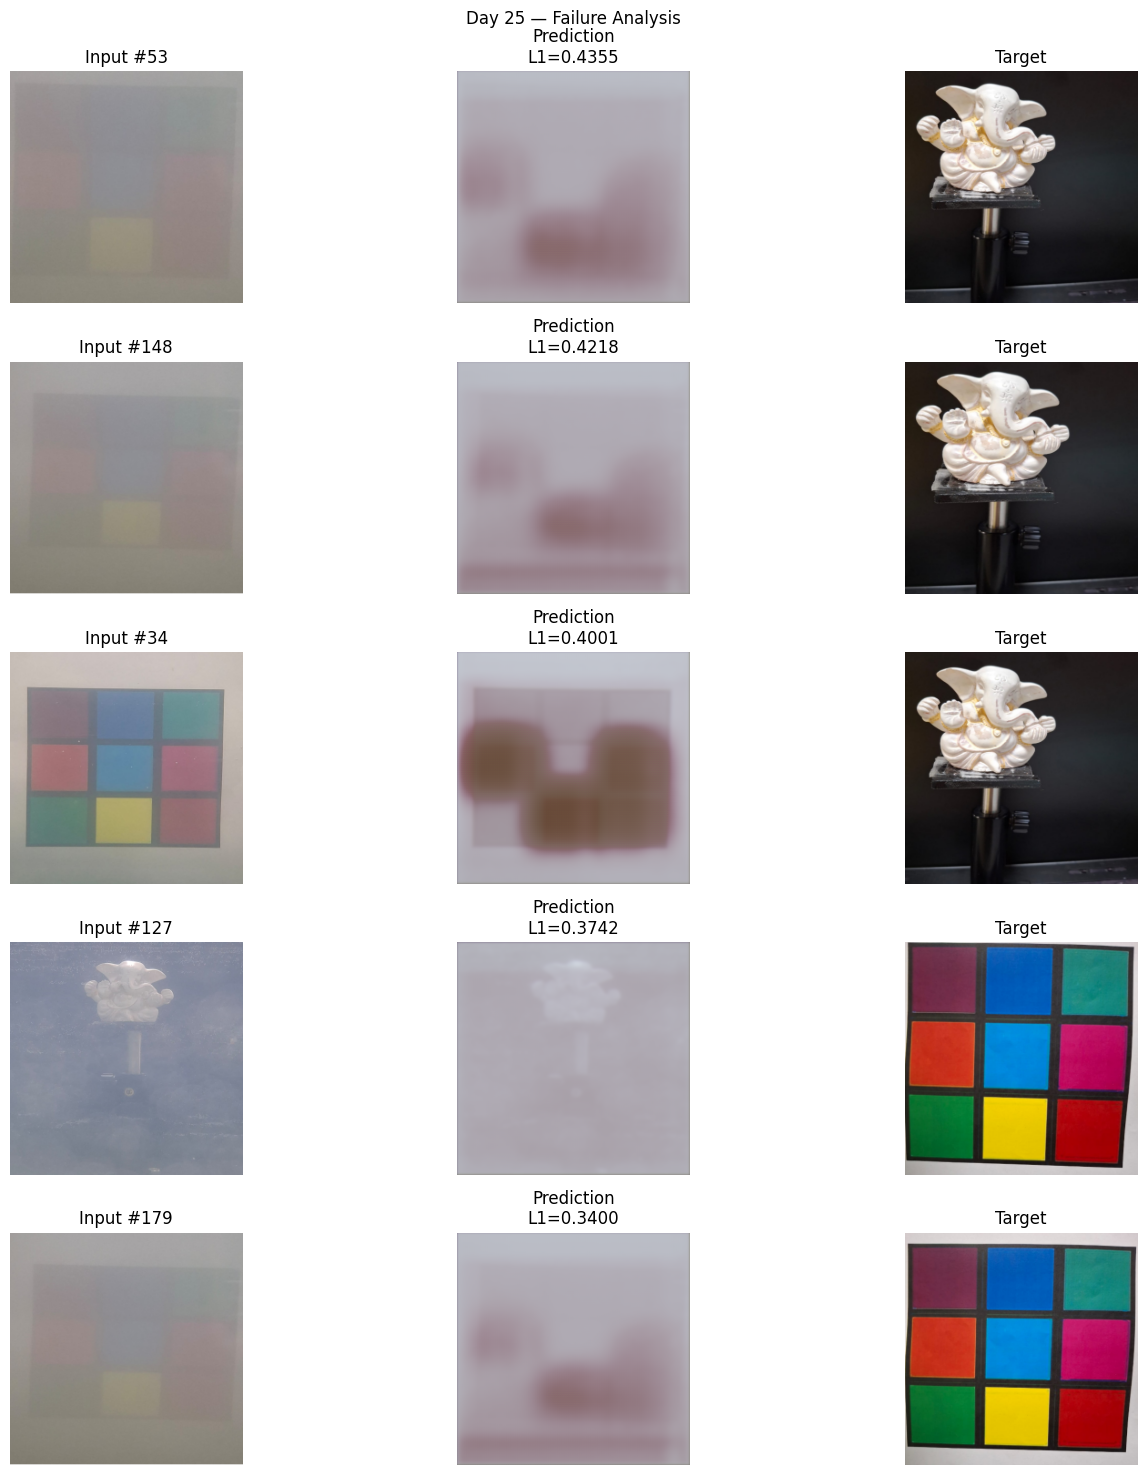

In [ ]:
num_failures = 5

plt.figure(
    figsize=(15, 15)
)

for row, idx in enumerate(
    failure_indices[:num_failures]
):

    input_img = (
        all_inputs[idx]
        .permute(1, 2, 0)
        .numpy()
    )

    output_img = (
        all_outputs[idx]
        .permute(1, 2, 0)
        .numpy()
    )

    target_img = (
        all_targets[idx]
        .permute(1, 2, 0)
        .numpy()
    )

    plt.subplot(
        num_failures,
        3,
        row * 3 + 1
    )

    plt.imshow(input_img)
    plt.title(
        f"Input #{idx}"
    )
    plt.axis("off")

    plt.subplot(
        num_failures,
        3,
        row * 3 + 2
    )

    plt.imshow(output_img)
    plt.title(
        f"Prediction\nL1={image_errors[idx]:.4f}"
    )
    plt.axis("off")

    plt.subplot(
        num_failures,
        3,
        row * 3 + 3
    )

    plt.imshow(target_img)
    plt.title("Target")
    plt.axis("off")

plt.suptitle(
    "Day 25 — Failure Analysis"
)

plt.tight_layout()
plt.show()

In [ ]:
channel_errors = []

for i in range(
    len(all_outputs)
):

    error = torch.mean(
        torch.abs(
            all_outputs[i]
            -
            all_targets[i]
        ),
        dim=(1, 2)
    ).numpy()

    channel_errors.append(error)

channel_errors = np.array(
    channel_errors
)

mean_channel_error = (
    channel_errors.mean(axis=0)
)

print(
    "RGB channel errors:"
)

print(
    "Red  :",
    mean_channel_error[0]
)

print(
    "Green:",
    mean_channel_error[1]
)

print(
    "Blue :",
    mean_channel_error[2]
)

RGB channel errors:
Red  : 0.16950355
Green: 0.17015727
Blue : 0.1879469


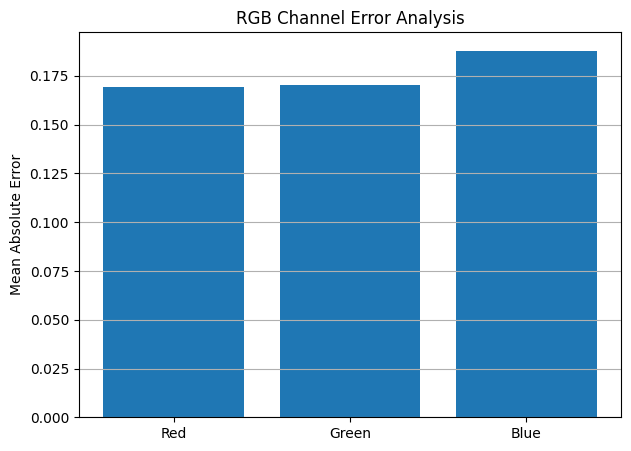

In [ ]:
plt.figure(
    figsize=(7, 5)
)

plt.bar(
    ["Red", "Green", "Blue"],
    mean_channel_error
)

plt.ylabel(
    "Mean Absolute Error"
)

plt.title(
    "RGB Channel Error Analysis"
)

plt.grid(
    axis="y"
)

plt.show()

In [ ]:
def combined_loss(
    prediction,
    target
):

    l1 = torch.mean(
        torch.abs(
            prediction - target
        )
    )

    # Simple structural-gradient component
    pred_dx = (
        prediction[:, :, :, 1:]
        -
        prediction[:, :, :, :-1]
    )

    target_dx = (
        target[:, :, :, 1:]
        -
        target[:, :, :, :-1]
    )

    pred_dy = (
        prediction[:, :, 1:, :]
        -
        prediction[:, :, :-1, :]
    )

    target_dy = (
        target[:, :, 1:, :]
        -
        target[:, :, :-1, :]
    )

    gradient_loss = (
        torch.mean(
            torch.abs(
                pred_dx - target_dx
            )
        )
        +
        torch.mean(
            torch.abs(
                pred_dy - target_dy
            )
        )
    )

    return (
        l1
        +
        0.1 * gradient_loss
    )

In [ ]:
gradient_errors = []

for i in range(
    len(all_outputs)
):

    prediction = (
        all_outputs[i:i+1]
    )

    target = (
        all_targets[i:i+1]
    )

    pred_dx = (
        prediction[:, :, :, 1:]
        -
        prediction[:, :, :, :-1]
    )

    target_dx = (
        target[:, :, :, 1:]
        -
        target[:, :, :, :-1]
    )

    pred_dy = (
        prediction[:, :, 1:, :]
        -
        prediction[:, :, :-1, :]
    )

    target_dy = (
        target[:, :, 1:, :]
        -
        target[:, :, :-1, :]
    )

    gradient_error = (
        torch.mean(
            torch.abs(
                pred_dx - target_dx
            )
        )
        +
        torch.mean(
            torch.abs(
                pred_dy - target_dy
            )
        )
    ).item()

    gradient_errors.append(
        gradient_error
    )

gradient_errors = np.array(
    gradient_errors
)

print(
    "Mean structural gradient error:",
    gradient_errors.mean()
)

Mean structural gradient error: 0.0390799790720946


In [ ]:
failure_statistics = {

    "test_samples":
        len(test_dataset),

    "mean_L1_error":
        float(image_errors.mean()),

    "maximum_L1_error":
        float(image_errors.max()),

    "minimum_L1_error":
        float(image_errors.min()),

    "mean_R_error":
        float(mean_channel_error[0]),

    "mean_G_error":
        float(mean_channel_error[1]),

    "mean_B_error":
        float(mean_channel_error[2]),

    "mean_gradient_error":
        float(gradient_errors.mean()),

    "worst_case_indices":
        failure_indices.tolist()
}

print(
    json.dumps(
        failure_statistics,
        indent=4
    )
)

{
    "test_samples": 186,
    "mean_L1_error": 0.1758692553367025,
    "maximum_L1_error": 0.43548646569252014,
    "minimum_L1_error": 0.07383019477128983,
    "mean_R_error": 0.16950355470180511,
    "mean_G_error": 0.1701572686433792,
    "mean_B_error": 0.18794690072536469,
    "mean_gradient_error": 0.0390799790720946,
    "worst_case_indices": [
        53,
        148,
        34,
        127,
        179,
        177,
        150,
        139,
        80,
        129
    ]
}


In [ ]:
analysis_path = os.path.join(
    DAY25_FOLDER,
    "Day25_Failure_Analysis.json"
)

with open(
    analysis_path,
    "w"
) as f:

    json.dump(
        failure_statistics,
        f,
        indent=4
    )

print(
    "Failure analysis saved:"
)

print(analysis_path)

Failure analysis saved:
/content/drive/MyDrive/Underwater-Image-Data-set-main/Day25_Results/Day25_Failure_Analysis.json


In [ ]:
failure_table = pd.DataFrame({

    "Test_Index":
        np.arange(
            len(image_errors)
        ),

    "L1_Error":
        image_errors,

    "Gradient_Error":
        gradient_errors

})

failure_table = failure_table.sort_values(
    by="L1_Error",
    ascending=False
)

failure_csv = os.path.join(
    DAY25_FOLDER,
    "Day25_Failure_Table.csv"
)

failure_table.to_csv(
    failure_csv,
    index=False
)

failure_table.head(10)

,Test_Index,L1_Error,Gradient_Error
53,53,0.435486,0.033159
148,148,0.421761,0.034997
34,34,0.400122,0.035879
127,127,0.374189,0.031455
179,179,0.339971,0.031727
177,177,0.307650,0.034319
150,150,0.284698,0.034112
139,139,0.277390,0.034458
80,80,0.275456,0.034615
129,129,0.260389,0.032446


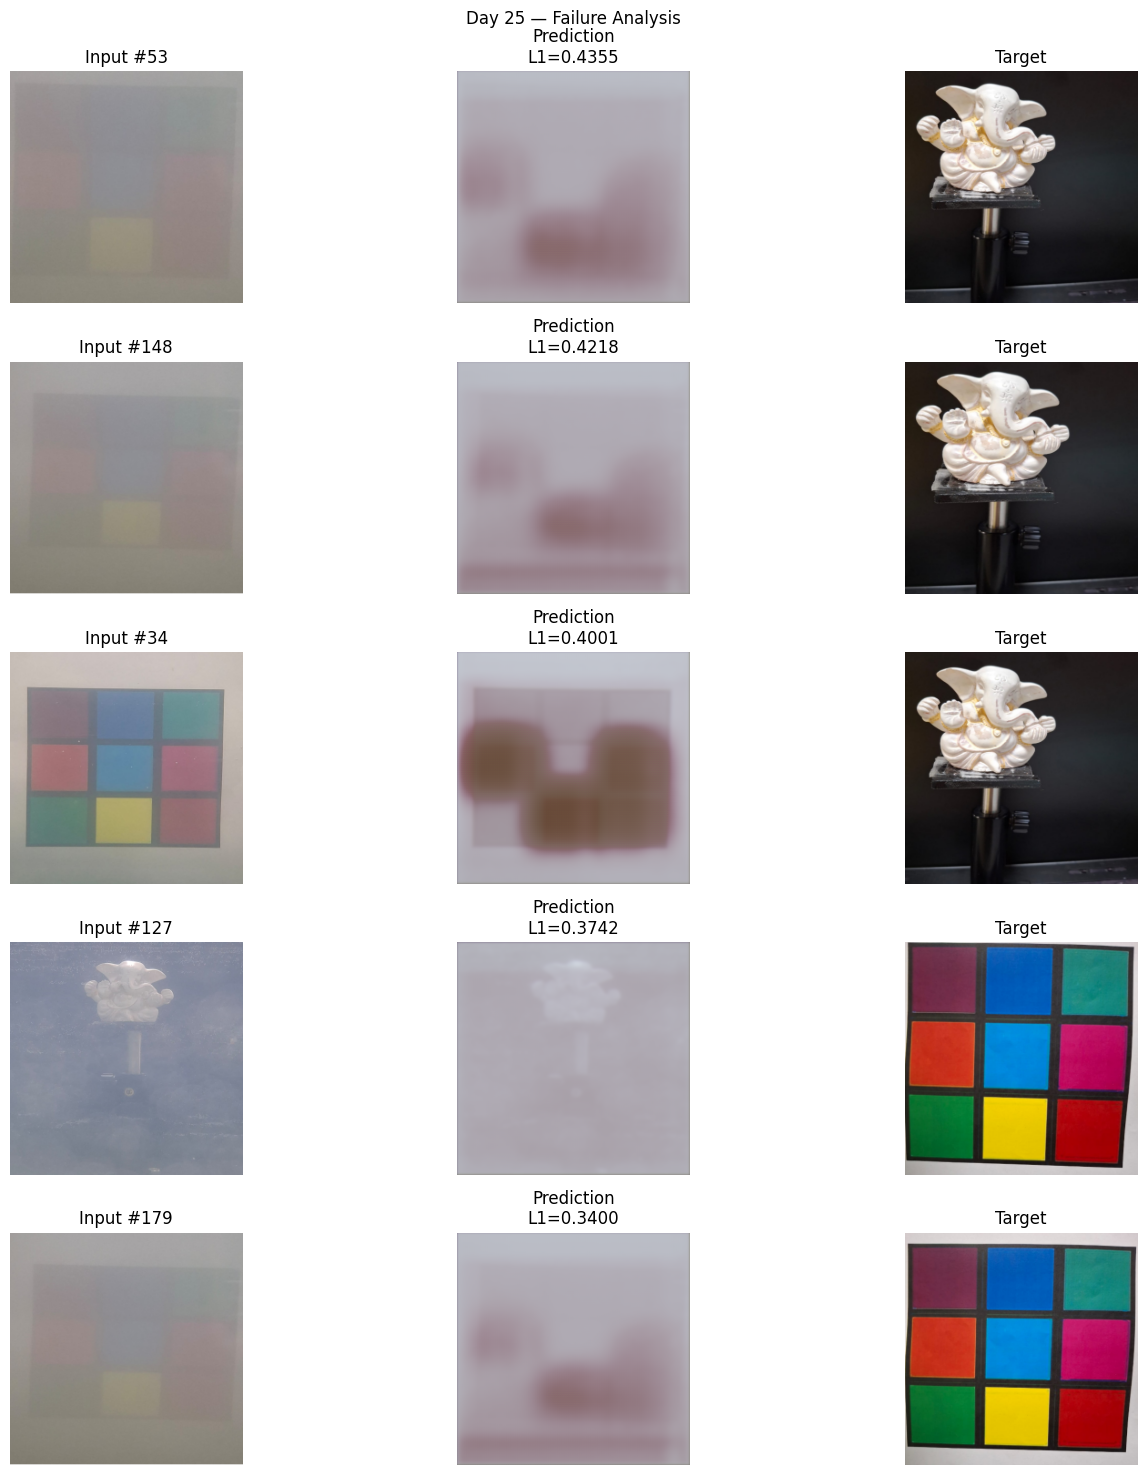

Saved: /content/drive/MyDrive/Underwater-Image-Data-set-main/Day25_Results/Day25_Failure_Cases.png


In [ ]:
failure_plot_path = os.path.join(
    DAY25_FOLDER,
    "Day25_Failure_Cases.png"
)

plt.figure(
    figsize=(15, 15)
)

for row, idx in enumerate(
    failure_indices[:5]
):

    input_img = (
        all_inputs[idx]
        .permute(1, 2, 0)
        .numpy()
    )

    output_img = (
        all_outputs[idx]
        .permute(1, 2, 0)
        .numpy()
    )

    target_img = (
        all_targets[idx]
        .permute(1, 2, 0)
        .numpy()
    )

    plt.subplot(
        5,
        3,
        row * 3 + 1
    )

    plt.imshow(input_img)
    plt.title(
        f"Input #{idx}"
    )
    plt.axis("off")

    plt.subplot(
        5,
        3,
        row * 3 + 2
    )

    plt.imshow(output_img)
    plt.title(
        f"Prediction\nL1={image_errors[idx]:.4f}"
    )
    plt.axis("off")

    plt.subplot(
        5,
        3,
        row * 3 + 3
    )

    plt.imshow(target_img)
    plt.title("Target")
    plt.axis("off")

plt.suptitle(
    "Day 25 — Failure Analysis"
)

plt.tight_layout()

plt.savefig(
    failure_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    failure_plot_path
)

In [ ]:
day25_report = f"""
DAY 25 — FAILURE ANALYSIS + TARGETED IMPROVEMENT

FINAL MODEL
Architecture: {final_config.get("model", "U-Net")}

TEST SET
Number of test samples: {len(test_dataset)}

FAILURE ANALYSIS
Mean L1 error: {image_errors.mean():.6f}
Maximum L1 error: {image_errors.max():.6f}
Minimum L1 error: {image_errors.min():.6f}

RGB CHANNEL ANALYSIS
Red error: {mean_channel_error[0]:.6f}
Green error: {mean_channel_error[1]:.6f}
Blue error: {mean_channel_error[2]:.6f}

STRUCTURAL ANALYSIS
Mean gradient error: {gradient_errors.mean():.6f}

TARGETED IMPROVEMENT
A gradient-aware component was investigated as an additional
structural loss term.

The Day 22 frozen model remains unchanged.
The Day 25 experiment is treated as an analysis/experimental
improvement and does not replace the frozen final model.

WORST CASES
{failure_indices.tolist()}
"""

report_path = os.path.join(
    DAY25_FOLDER,
    "Day25_Report.txt"
)

with open(
    report_path,
    "w"
) as f:

    f.write(day25_report)

print(day25_report)

print(
    "\nReport saved:",
    report_path
)


DAY 25 — FAILURE ANALYSIS + TARGETED IMPROVEMENT

FINAL MODEL
Architecture: U-Net

TEST SET
Number of test samples: 186

FAILURE ANALYSIS
Mean L1 error: 0.175869
Maximum L1 error: 0.435486
Minimum L1 error: 0.073830

RGB CHANNEL ANALYSIS
Red error: 0.169504
Green error: 0.170157
Blue error: 0.187947

STRUCTURAL ANALYSIS
Mean gradient error: 0.039080

TARGETED IMPROVEMENT
A gradient-aware component was investigated as an additional
structural loss term.

The Day 22 frozen model remains unchanged.
The Day 25 experiment is treated as an analysis/experimental
improvement and does not replace the frozen final model.

WORST CASES
[53, 148, 34, 127, 179, 177, 150, 139, 80, 129]


Report saved: /content/drive/MyDrive/Underwater-Image-Data-set-main/Day25_Results/Day25_Report.txt
